In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DURATION_MS = 1000
TAU = 20.0
V_THRESH = 0.6

ETA = 0.001

ALPHA = np.exp(-1.0 / TAU)

In [3]:
def gen_spikes(rate):
    spike_vec = np.zeros(DURATION_MS)
    for t in range(DURATION_MS):
        spike_vec[t] = np.random.poisson(rate / 1000.0)
        
    return spike_vec

pre_spike_vec = np.minimum(1.0, gen_spikes(50.0))
post_spike_vec = gen_spikes(50.0 * 256)

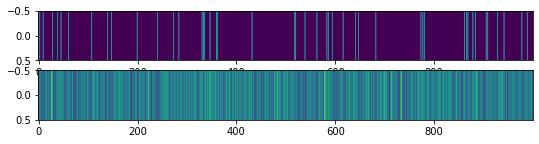

In [4]:
fig, axes = plt.subplots(2, figsize=(16,2))
axes[0].imshow(pre_spike_vec[np.newaxis,:])
axes[1].imshow(post_spike_vec[np.newaxis,:])
axes[0].set_aspect(100)
axes[1].set_aspect(100)

## Time-driven neuron state

In [5]:
z_pre_rec = []
z_pre = 0.0

v_post_rec = []
v_post = 0.0
psi_post_rec = []

refrac_time_post = 0.0
weight = 0.0025

for t in range(DURATION_MS):
    z_pre = (z_pre * ALPHA) + pre_spike_vec[t]
    v_post = (v_post * ALPHA) + (weight * post_spike_vec[t])
    
    if refrac_time_post > 0.0:
        refrac_time_post -= 1
        psi_post_rec.append(0)
    else:
        psi_post_rec.append(0.5 if v_post > 0.3 else 0.0)
        if v_post > V_THRESH:
            v_post -= V_THRESH
            refrac_time_post = 5
        
    z_pre_rec.append(z_pre)
    v_post_rec.append(v_post)

z_pre_rec = np.asarray(z_pre_rec)
v_post_rec = np.asarray(v_post_rec)
psi_post_rec = np.asarray(psi_post_rec)

## Visualize time-driven neuron activity

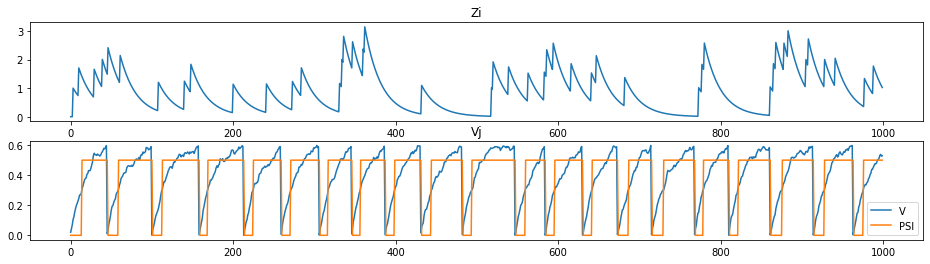

In [6]:
fig, axes = plt.subplots(2, figsize=(16, 4))
axes[0].plot(z_pre_rec)
axes[1].plot(v_post_rec, label="V")
axes[1].plot(psi_post_rec, label="PSI")

axes[0].set_title("Zi")
axes[1].set_title("Vj")
axes[1].legend()

In [7]:
learning_signal = np.concatenate((np.ones(DURATION_MS // 4), 
                                  np.zeros(DURATION_MS // 4),
                                  -np.ones(DURATION_MS // 4), 
                                  np.ones(DURATION_MS // 4) * 0.5))


## Time-driven eligibility trace and learning

In [8]:
e_filt_time = 0.0
e_filt_time_rec = []
weight_time = 0.0
weight_time_rec = []

for t in range(DURATION_MS):
    e_time = z_pre_rec[t] * psi_post_rec[t]
    e_filt_time = (e_filt_time * ALPHA) + e_time
    e_filt_time_rec.append(e_filt_time)
    
    weight_time -= ETA * learning_signal[t] * e_filt_time
    weight_time_rec.append(weight_time)


## Visualise time-driven eligibility trace and learning

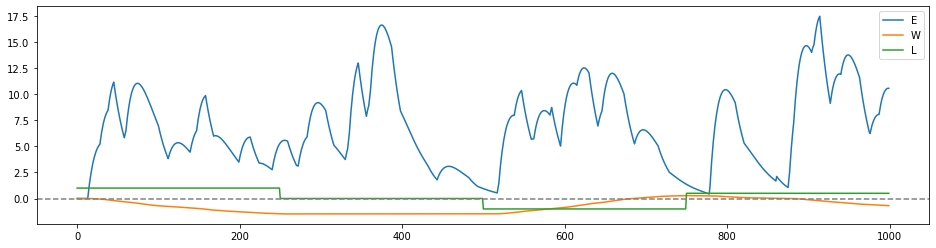

In [9]:
fig, axis = plt.subplots(figsize=(16, 4))
axis.plot(e_filt_time_rec, label="E")
axis.plot(weight_time_rec, label="W")
axis.plot(learning_signal, label="L")
axis.axhline(0, linestyle="--", color="gray")
axis.legend()

## Event-driven eligibiltity trace

In [29]:
def update(t, last_update_time, last_pre_update_time, z_pre_event, e_filt_event, psi, learning, w):
    exp_pre_delta_t = np.exp(-(t - last_pre_update_time) / TAU)
    exp_delta_t = np.exp(-(t - last_update_time) / TAU)
    tau_exp_delta_t = TAU * exp_delta_t
    tau_exp_delta_t_minus_one = TAU * (exp_delta_t - 1.0)
    delta_g = -ETA * learning * (
        psi * z_pre_event * ((TAU * (TAU + last_update_time)) - (tau_exp_delta_t * (t + TAU))
                             + last_update_time * tau_exp_delta_t_minus_one)
        - (e_filt_event * tau_exp_delta_t_minus_one))
    w += delta_g
    
    # Update elgibility
    e_filt_event = ((t - last_update_time) * psi * z_pre_event * exp_pre_delta_t) + (e_filt_event * exp_delta_t)

    return e_filt_event, w

# Get pre-spike times
pre_spike_times = np.where(pre_spike_vec == 1.0)[0]

# Get times where psi changes
psi_change = (psi_post_rec[1:] - psi_post_rec[:-1])

# Get times where learning rate changes
learning_change = (learning_signal[1:] - learning_signal[:-1])

# Add together to get a vector with non-zero whenever something postsynaptic changes
post_changes = psi_change + learning_change

# Extract times of postsynaptic changes
post_change_times = np.where(post_changes != 0)[0] + 1

# Indices of next pre-spike or postsynaptic change
next_pre_spike_idx = 0
next_post_change_idx = 0

e_filt_event = 0.0
e_filt_event_rec = []
z_pre_event = 0.0
z_pre_event_rec = []
last_pre_update_time = 0
last_update_time = 0
weight_event_rec = []
weight_event = 0
psi = 0.0
learning = 1.0
for t in range(DURATION_MS):   
    # If presynaptic spike occurs at this time
    # **NOTE** in GeNN implementation, this would be a presynaptic spike
    if next_pre_spike_idx < len(pre_spike_times) and t == pre_spike_times[next_pre_spike_idx]:
        # Update pre trace 
        # **NOTE** in GeNN this happens in neuron kernel
        z_pre_event = (z_pre_event * np.exp(-(t - last_pre_update_time) / TAU)) + 1.0
        last_pre_update_time = t
        
        # Make update
        (e_filt_event, weight_event) =\
            update(t, last_update_time, last_pre_update_time, z_pre_event - 1.0, e_filt_event, psi, learning, weight_event)
  
        # Record stuff
        e_filt_event_rec.append((t, e_filt_event))
        z_pre_event_rec.append((t, z_pre_event))
        weight_event_rec.append((t, weight_event))

        # Update state
        last_update_time = t
        
        next_pre_spike_idx += 1

    # If postsynaptic change occurs at this time
    # **NOTE** in GeNN implementation, this would be a postsynaptic spike-like event
    if next_post_change_idx < len(post_change_times) and t == post_change_times[next_post_change_idx]:
        # Make update
        e_filt_event, weight_event =\
            update(t, last_update_time, last_pre_update_time, z_pre_event, e_filt_event, psi, learning, weight_event)
        
        # Record stuff
        e_filt_event_rec.append((t, e_filt_event))
        weight_event_rec.append((t, weight_event))
        
        # Update psi and learning
        psi = psi_post_rec[t]
        learning = learning_signal[t]
        
        # Update state
        last_update_time = t
        next_post_change_idx += 1

# 'Transpose' recorded events for ease of plotting
z_pre_event_rec = list(zip(*z_pre_event_rec))
e_filt_event_rec = list(zip(*e_filt_event_rec))
weight_event_rec = list(zip(*weight_event_rec))

## Visualize event-based Zi

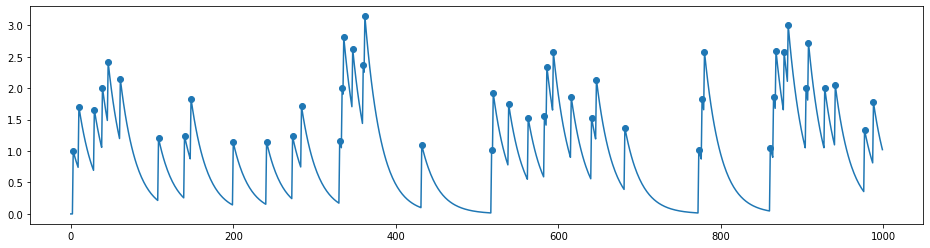

In [30]:
fig, axis = plt.subplots(figsize=(16, 4))
axis.plot(z_pre_rec)
axis.scatter(z_pre_event_rec[0], z_pre_event_rec[1])

## Visualize event-based Eji

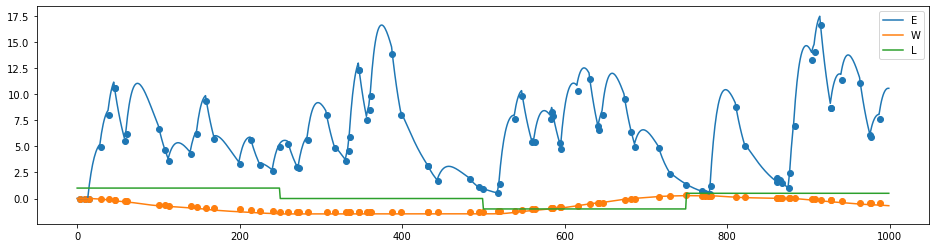

In [31]:
fig, axis = plt.subplots(figsize=(16, 4))

e_act = axis.plot(e_filt_time_rec, label="E")[0]
axis.scatter(e_filt_event_rec[0], e_filt_event_rec[1], color=e_act.get_color())

w_act = axis.plot(weight_time_rec, label="W")[0]
axis.scatter(weight_event_rec[0], weight_event_rec[1], color=w_act.get_color())

axis.plot(learning_signal, label="L")
axis.legend()